In [1]:
import numpy as np
import pandas as pd

# Plantilla

Es necesario ajustar las definiciones, las fuentes de los datos y posiblemente definiciones si la ENEMDU tiene una dimensión geográfica y temporal al mismo tiempo

In [2]:
data = pd.read_stata(r"Z:\harmonized\ECU\ENEMDU\data_arm\ECU_1990m11_BID.dta") # para bases de stata
# data = pd.read_stata(r"Z:\survey\ECU\ENEMDU\1990\m11\data_orig\ECU_1990m11.dta") # para bases de stata
# data = pd.read_stata(r"datos/ECU_1990m11_BID.dta") # para bases de stata

## Revisar los datos

- rn - región natural
- estrato - estrato
- cuidad - ciudad
- zona - zona
- sector - sector
- conglo - conglomerado
- area - area
- vivienda - vivienda
- hogar - hogar
- persona - persona
- numpers - número de personas
- edad - edad
- ingesper - ingreso esperado por ese trabajo
- salbasic - salario básico (puede ser usarlo para discrimnar regiones)
- rulpago - cuánto recibió en el último pago (puede ser mejor que ingesper)
- gefec - cuánto retiro de su negocio en efectivo
- gmerc - cuánto retiro de su negocio en mercaderías
- valren - valor de ingreso por rentas
- valjub - valor de ingreso por jubilación
- valoti - valor de otros ingresos
- fexp - factor de expansión
- ingrl - ingreso (suma gefec y gmerc)

El valor de 'salbasic' es el ingreso laboral monetario, no hay datos sobre ingreso laboral no monetario hay relación entre 'salbasic' y 'rulpago' y 'formapago'.
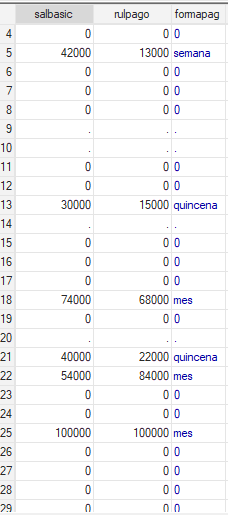 

Hay variables dicotomicas para cada mes (ene, feb, mar, abr, may, jun, jul, ago, sep, oct, nov, dic) que dicen si estuvo o no ocupado, se puede usar estas variables y el salario básico asumiendo que cuando estaba ocupado tenía ese salario para intentar aproximar el salario mensual y de ahí el salario trimestral, esto solo funciona así ya que no tenemos una variable que explicite el mes, en encuestas que tengan el mes o trimestre explícito esto no sería igual.

Segunda revisión, intentamos probar con el valor de rulpago que es el último pago que recibió siempre que formapag = 1 es decir pago mensual, siguiendo la metodología del BID

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Columns: 267 entries, rn to ratio_cpi2017
dtypes: category(80), float32(26), float64(119), int16(7), int32(1), int8(29), object(5)
memory usage: 43.4+ MB


Filtramos solo las columnas de interés para alivar el peso en la memoria

In [4]:
data.columns

Index(['rn', 'estrato', 'ciudad', 'zona', 'sector', 'conglo', 'area',
       'vivienda', 'hogar', 'formul',
       ...
       'lp5_2011', 'lp365_2017', 'lp685_2017', 'lp14_2017', 'lp81_2017',
       'tc_c', 'ppp_c', 'cpi_c', 'ratio_cpi2011', 'ratio_cpi2017'],
      dtype='object', length=267)

In [5]:
data = data[['rn', 'estrato', 'ciudad', 'zona', 'sector', 'conglo', 'area', 'vivienda', 'hogar', 'persona', 'numpers', 'edad', 'ingesper', 'salbasic',
      'gefec', 'gmerc', 'rulpago', 'formapag', 'valren', 'valjub', 'valoti', 'fexp', 'ingrl', 'ene', 'feb', 'mar', 'abr', 'may', 'jun', 'jul', 'ago', 'sep', 'oct', 'nov', 'dic']]

Ingreso mensual asumiendo que las personas reciben el mismo valor reportado en 'rulpago' siempre que 'formapag' sea igual a 1, siguiendo metodología del BID y está ocupado en el mes

In [6]:
data['ingr_ene'] = data.apply(lambda x: x['rulpago'] if x['ene'] == 'ocupado' else None, axis=1)

In [7]:
data['ingr_ene'] = data.apply(lambda x: x['rulpago'] if (x['ene'] == 'ocupado') & (x['formapag'] == 1) else None, axis=1)

In [8]:
data['ingr_ene'].mean()

nan

In [9]:
data['ingr_ene'] = data.apply(lambda x: x['rulpago'] if (x['ene'] == 'ocupado') & (x['formapag'] == 1) else None, axis=1)
data['ingr_feb'] = data.apply(lambda x: x['salbasic'] if x['feb'] == 'ocupado' else None, axis=1)
data['ingr_mar'] = data.apply(lambda x: x['salbasic'] if x['mar'] == 'ocupado' else None, axis=1)
data['ingr_abr'] = data.apply(lambda x: x['salbasic'] if x['abr'] == 'ocupado' else None, axis=1)
data['ingr_may'] = data.apply(lambda x: x['salbasic'] if x['may'] == 'ocupado' else None, axis=1)
data['ingr_jun'] = data.apply(lambda x: x['salbasic'] if x['jun'] == 'ocupado' else None, axis=1)
data['ingr_jul'] = data.apply(lambda x: x['salbasic'] if x['jul'] == 'ocupado' else None, axis=1)
data['ingr_ago'] = data.apply(lambda x: x['salbasic'] if x['ago'] == 'ocupado' else None, axis=1)
data['ingr_sep'] = data.apply(lambda x: x['salbasic'] if x['sep'] == 'ocupado' else None, axis=1)
data['ingr_oct'] = data.apply(lambda x: x['salbasic'] if x['oct'] == 'ocupado' else None, axis=1)
data['ingr_nov'] = data.apply(lambda x: x['salbasic'] if x['nov'] == 'ocupado' else None, axis=1)
data['ingr_dic'] = data.apply(lambda x: x['salbasic'] if x['dic'] == 'ocupado' else None, axis=1)

## Deflactamos y transformamos el ingreso

Esto deja todo en dólares constantes de 2014, utilizamos el IPC de Estados Unidos para ajustar por inflación ya que no podemos usar la inflación en sucres si queremos dejar el valor final en dólares de 2014

In [10]:
# Carga base de datos con ipc
data_externa = pd.read_excel("data_externa.xlsx", sheet_name='datos')

# filtra año de interés
datos_actual = data_externa[data_externa['Año'] == 1990]
datos_base = data_externa[data_externa['Año'] == 2014]

Diccionarios de ipc y tipo de cambio

In [11]:
ipc_dict = dict(zip(datos_actual['trimestre'], datos_actual['IPC Estados Unidos']))

ipc_base_dict = dict(zip(datos_base['trimestre'], datos_base['IPC Estados Unidos']))

tipo_cambio_dict = dict(zip(datos_actual['trimestre'], datos_actual['tipo de cambio']))

### Asignamos el ipc y tipo de cambio correspondiente según trimestre

$\begin{equation}
    ingr_{USD-base-2014}^{i} = \frac{ingr_{sucres}^{i}}{tipo-de-cambio^{i}}\left( \frac{ipcUSA^{i}_{2014}}{ipcUSA^{i}_{año}}\right)
\end{equation}$

Con $i$ el trimestre de interés y $año$ el año de interés

In [12]:
# Función que asigna valores correspondientes
def asigna_ipc(trimestre):
    return ipc_dict.get(trimestre, {})

def asigna_ipc_base(trimestre):
    return ipc_base_dict.get(trimestre, {})

In [13]:
data['ipc_t1'] = ipc_dict.get(1)
data['ipc_base_t1'] = ipc_base_dict.get(1)
data['tipo_cambio_t1'] = tipo_cambio_dict.get(1)

data['ipc_t2'] = ipc_dict.get(2)
data['ipc_base_t2'] = ipc_base_dict.get(2)
data['tipo_cambio_t2'] = tipo_cambio_dict.get(2)

data['ipc_t3'] = ipc_dict.get(3)
data['ipc_base_t3'] = ipc_base_dict.get(3)
data['tipo_cambio_t3'] = tipo_cambio_dict.get(3)

data['ipc_t4'] = ipc_dict.get(4)
data['ipc_base_t4'] = ipc_base_dict.get(4)
data['tipo_cambio_t4'] = tipo_cambio_dict.get(4)

In [14]:
# Calculamos el deflactor
data['def_t1'] = (data['ipc_base_t1'] / data['ipc_t1'])
data['def_t2'] = (data['ipc_base_t2'] / data['ipc_t2'])
data['def_t3'] = (data['ipc_base_t3'] / data['ipc_t3'])
data['def_t4'] = (data['ipc_base_t4'] / data['ipc_t4'])

In [15]:
# Ingreso real por mes
data['ingr_ene_r'] = (data['ingr_ene'] / data['tipo_cambio_t1']) * data['def_t1']
data['ingr_feb_r'] = (data['ingr_feb'] / data['tipo_cambio_t1']) * data['def_t1']
data['ingr_mar_r'] = (data['ingr_mar'] / data['tipo_cambio_t1']) * data['def_t1']
data['ingr_abr_r'] = (data['ingr_abr'] / data['tipo_cambio_t2']) * data['def_t2']
data['ingr_may_r'] = (data['ingr_may'] / data['tipo_cambio_t2']) * data['def_t2']
data['ingr_jun_r'] = (data['ingr_jun'] / data['tipo_cambio_t2']) * data['def_t2']
data['ingr_jul_r'] = (data['ingr_jul'] / data['tipo_cambio_t3']) * data['def_t3']
data['ingr_ago_r'] = (data['ingr_ago'] / data['tipo_cambio_t3']) * data['def_t3']
data['ingr_sep_r'] = (data['ingr_sep'] / data['tipo_cambio_t3']) * data['def_t3']
data['ingr_oct_r'] = (data['ingr_oct'] / data['tipo_cambio_t4']) * data['def_t4']
data['ingr_nov_r'] = (data['ingr_nov'] / data['tipo_cambio_t4']) * data['def_t4']
data['ingr_dic_r'] = (data['ingr_dic'] / data['tipo_cambio_t4']) * data['def_t4']

Ingreso mensual promedio en el trimeste

In [16]:
data['ingr_t1_r'] = (data['ingr_ene_r'] + data['ingr_feb_r'] + data['ingr_mar_r'])/3
data['ingr_t2_r'] = (data['ingr_abr_r'] + data['ingr_may_r'] + data['ingr_jun_r'])/3
data['ingr_t3_r'] = (data['ingr_jul_r'] + data['ingr_ago_r'] + data['ingr_sep_r'])/3
data['ingr_t4_r'] = (data['ingr_oct_r'] + data['ingr_nov_r'] + data['ingr_dic_r'])/3

In [17]:
print(data['ingr_t1_r'].mean())
print(data['ingr_t2_r'].mean())
print(data['ingr_t3_r'].mean())
print(data['ingr_t4_r'].mean())

nan
67.83362841792396
61.48716902132288
60.97520180876264


## Regiones

In [20]:
print(data['ciudad'][0])

10150


In [35]:
fac = data['ciudad'].apply(lambda x: len(str(x))).min()
fac

5

In [36]:
# Corregimos los códigos para usarlos cómo texto
data['ciudad'] = data['ciudad'].apply(str)
data['ciudad'] = data['ciudad'].apply(lambda x: '0' + x if len(x) == fac else x)

data['ciudad_2'] = data['ciudad'].apply(lambda x: x[:2])

In [37]:
regiones_dict = {
    'Guayas': '09',
    'Manabí': '13',
    'El Oro': '07',
    'Los Ríos': '12',
    'Pichincha': '17',
    'Azuay': '01',
    'Galápagos': '20',
    'Sierra': ['04', '10', '05', '18', '02', '06', '03', '11'],
    'Costa, Santo Domingo': ['08', '24', '23'],
    'Amazonía': ['14', '15', '16', '19', '21', '22', '90']
}

In [38]:
codigo_region = {}
for region, codes in regiones_dict.items():
    
    if isinstance(codes, list):
        for code in codes:
            codigo_region[code] = region
    
    else:
        codigo_region[codes] = region

# Mapeo de regiones
data['region'] = data['ciudad_2'].map(codigo_region)

In [39]:
data['region'].value_counts()

region
Guayas                  9756
Pichincha               7088
Sierra                  5596
Manabí                  3010
El Oro                  2977
Amazonía                2827
Azuay                   2791
Los Ríos                1977
Costa, Santo Domingo    1194
Name: count, dtype: int64

## Calculo ingreso de los hogares

In [40]:
columnas_idef = ['rn', 'estrato', 'ciudad', 'zona', 'sector', 'conglo', 'area', 'vivienda', 'hogar']

data['idef_hogar'] = data[columnas_idef].astype(str).agg(''.join, axis=1)
len(data['idef_hogar'].unique())

7910

In [41]:
data[['rn', 'estrato', 'ciudad', 'zona', 'sector', 'conglo', 'area', 'vivienda', 'hogar', 'idef_hogar', 'persona', 'numpers']]

,rn,estrato,ciudad,zona,sector,conglo,area,vivienda,hogar,idef_hogar,persona,numpers
0,1,3,010150,1,5,01,1,1,1,130101501501111,3,3
1,1,3,010150,1,5,01,1,1,1,130101501501111,2,3
2,1,3,010150,1,5,01,1,1,1,130101501501111,1,3
3,1,3,010150,1,5,01,1,2,1,130101501501121,1,2
4,1,3,010150,1,5,01,1,2,1,130101501501121,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
37211,3,4,210450,1,11,01,1,12,1,34210450111011121,2,6
37212,3,4,210450,1,11,01,1,12,1,34210450111011121,5,6
37213,3,4,210450,1,11,01,1,12,1,34210450111011121,4,6
37214,3,4,210450,1,11,01,1,12,1,34210450111011121,1,6


Si todos los miembros del hogar tienen NA como ingreso, mantener NA, si al menos uno tiene un ingreso sumamos para el ingreso del hogar, así evitamos subestimar el ingreso del hogar si tenemos valores perdidos

In [42]:
# Definimos una función que sume pero devuelva NA si todos son NA
def sum_with_na(series):
    if series.isna().all():
        return pd.NA
    else:
        return series.sum(skipna=True)

In [43]:
data['ingr_t1_h'] = data.groupby('idef_hogar')['ingr_t1_r'].transform(sum_with_na)
data['ingr_t2_h'] = data.groupby('idef_hogar')['ingr_t2_r'].transform(sum_with_na)
data['ingr_t3_h'] = data.groupby('idef_hogar')['ingr_t3_r'].transform(sum_with_na)
data['ingr_t4_h'] = data.groupby('idef_hogar')['ingr_t4_r'].transform(sum_with_na)

In [44]:
data[['ingr_t1_h', 'ingr_t2_h', 'ingr_t3_h', 'ingr_t4_h']].mean()

ingr_t1_h           NaN
ingr_t2_h    133.346453
ingr_t3_h    122.640772
ingr_t4_h     119.44304
dtype: object

## Sacamos edades negativas y mayores a 100 años

In [45]:
len(data)

37216

En este caso en la variable edad tenemos números y el texto 'menos de un año' así que primero transformamos todas las filas que digan 'menos de un año' a 0

In [46]:
data['edad'] = data['edad'].apply(lambda x: x if type(x) == int else 0)

In [47]:
data = data.loc[(data['edad'] >= 0) & (data['edad'] < 100)]
len(data)

37216

## Ingreso individual descontando cargas familiares

Utilizando la metodología del autor dividimos el ingreso del hogar para la escala $(A_{i}+kC_{i})^{s}$ donde $A_{i}$ es al número de adultos, $C_{i}$ es el número de niños en el hogar $i$. $k$ es el costo en recursos de cada niño y $s$ busca reflejar las restricciones

In [48]:
k = 0.4
s = 0.9

In [49]:
# Si es necesario calcular el número de niños
data['es_nino'] = data['edad'] < 10

data['ninos'] = data.groupby('idef_hogar')['es_nino'].transform('sum')

# Si es necesario calcular el número de adultos
data['es_adulto'] = data['edad'] > 10

data['adultos'] = data.groupby('idef_hogar')['es_adulto'].transform('sum')

In [50]:
data['escala'] = (data['adultos'] + k * data['ninos']) ** s

In [51]:
data['ingr_t_t1'] = data['ingr_t1_h'] / data['escala']
data['ingr_t_t2'] = data['ingr_t2_h'] / data['escala']
data['ingr_t_t3'] = data['ingr_t3_h'] / data['escala']
data['ingr_t_t4'] = data['ingr_t4_h'] / data['escala']

In [52]:
data[['ingr_t_t1', 'ingr_t_t2', 'ingr_t_t3', 'ingr_t_t4']]

,ingr_t_t1,ingr_t_t2,ingr_t_t3,ingr_t_t4
0,<NA>,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>
3,<NA>,49.763158,45.197154,44.874396
4,<NA>,49.763158,45.197154,44.874396
...,...,...,...,...
37211,<NA>,52.356987,47.552987,47.213406
37212,<NA>,52.356987,47.552987,47.213406
37213,<NA>,52.356987,47.552987,47.213406
37214,<NA>,52.356987,47.552987,47.213406


In [53]:
print("Ingreso individual descontando cargas familiares t4: ", data['ingr_t_t4'].mean())
print("Mediana del ingreso individual descontando cargas familiares t4: ", data['ingr_t_t4'].median())

Ingreso individual descontando cargas familiares t4:  31.407670581586967
Mediana del ingreso individual descontando cargas familiares t4:  22.14461124189624


## Umbrales de pobreza

Incluimos los índices de pobreza si es posible a nivel regional para luego poder utilizar de mejor forma el factor de expansión

$\begin{equation}
    umbral_{USD-base-2014}^{i} = umbral_{año}\left( \frac{ipc^{i}_{2014}}{ipc^{i}_{año}}\right)
\end{equation}$

Con $i$ el trimestre de interés y $año$ el año de interés

Diccionario de umbral

In [54]:
umbral_dict = dict(zip(datos_actual['trimestre'], datos_actual['umbral de pobreza']))
salario_dict = dict(zip(datos_actual['trimestre'], datos_actual['salario básico unificado']))
ano = 1990

## Cálculo del índice de pobreza de Foster, Greer y Thorbecke

Para calcular un ínidce de pobreza se utiliza a Foster, Greer y Thorbecke (1984), ya que satisface algunas caracterísitcas de distribución que son positivas e igual a las enunciadas por Sen, el autor usa el mismo índice.

$\begin{equation}FGT_{\alpha} = \frac{1}{N}\sum_{i=1}^{H}\left(\frac{z-y_{i}}{z}\right)^{\alpha}\end{equation}$

Donde $z$ es el umbral de pobreza, $N$ es el número de personas en la economía, $H$ es el número de pobres (personas debajo de la línea de pobreza) $y_{i}$ es el ingreso de cada individuo. Mientras mayor es el valor de $\alpha$ mayor es el peso de los individuos más pobres, mayor $FGT$ mayor pobreza en la economía.

En este caso los umbrales están anivel nacional, aún así buscamos calcular la pobreza por región y sacar un promedio ponderado por región para la pobreza nacional, con el objetivo de hacerlo más específico

## Calculo del índice de desigualdad de Atkinson

Vamos a calcular el índice de desigualdad de atkinson con un parámetro $\epsilon$ de aversión a la desigualdad y un $\mu$ que es igual a la media de los ingresos individuales, con la siguiente fórmula.

$\begin{equation}A = 1-\frac{1}{\mu}\left(\frac{1}{N}\sum_{i=1}^{N}y^{1-\epsilon}\right)^{1/(1-\epsilon)}\end{equation}$

Donde $y_{i}$ es el ingreso individual y $\mu$ es el ingreso medio

In [55]:
resultados_list = []

# Para cada trimeste
for t in [1, 2, 3, 4]:
    salario = salario_dict.get(t)
    col_ingr = f'ingr_t_t{t}'
    umbral = umbral_dict.get(t)
    
    # Agrupa por región
    grouped = data.groupby('region')
    
    for region_name, group in grouped:
        # 1. Filtra datos
        valid = group.dropna(subset=[col_ingr])
        
        if len(valid) == 0:
            continue
            
        # Extrae los vectores 
        ingresos = valid[col_ingr].values
        pesos = valid['fexp'].values
        
        # 2. Calcula indices
        gaps = (umbral - ingresos) / umbral
        gaps = np.clip(gaps, a_min=0, a_max=None)
        
        # 3. Calcula FGT
        total_poblacion = pesos.sum()
        
        # FGT0
        fgt0 = (pesos * (gaps > 0).astype(int)).sum() / total_poblacion
        
        # FGT1
        fgt1 = (pesos * (gaps ** 1)).sum() / total_poblacion
        
        # FGT2
        fgt2 = (pesos * (gaps ** 2)).sum() / total_poblacion
        
        # 4. Calcula Ingreso promedio
        ingreso_promedio = np.average(ingresos, weights=pesos)

        # 5. Desigualdad de Atkinson
        atkinson_resultados = {}
        
        if ingreso_promedio > 0:
            for epsilon in [0.25, 0.5, 0.75]:
                # La suma ponderada de la utilidad
                utility_sum = np.sum((ingresos ** (1 - epsilon)) * pesos)
                
                # promedio de esa utilidad
                utility_mean = utility_sum / total_poblacion
                
                # ingreso equivalente
                y_ede = utility_mean ** (1 / (1 - epsilon))
                
                # índice final
                atkinson_index = 1 - (y_ede / ingreso_promedio)
                atkinson_resultados[f'a{int(epsilon*100)}'] = atkinson_index
        else:
            # Si nadie gana nada, definimos desigualdad como NaN
            atkinson_resultados = {'a25': np.nan, 'a50': np.nan, 'a75': np.nan}

        # 6. Calcula mediana del ingreso
        # Ordena
        sort_idx = np.argsort(ingresos)
        ingreso_ordenado = ingresos[sort_idx]
        pesos_ordenado = pesos[sort_idx]
        cumsum_pesos = np.cumsum(pesos_ordenado)
        cutoff = total_poblacion / 2.0
        mediana = ingreso_ordenado[np.searchsorted(cumsum_pesos, cutoff)]
        
        # 7. Guarda resultados
        resultados_list.append({
            'ano': ano,
            'trimestre': t,
            'region': region_name,
            'fgt0': fgt0,
            'fgt1': fgt1,
            'fgt2': fgt2,
            'a25': atkinson_resultados['a25'],
            'a50': atkinson_resultados['a50'],
            'a75': atkinson_resultados['a75'],
            'ingreso_promedio': ingreso_promedio,
            'ingreso_mediana': mediana,
            'salario_minimo': salario,
            'kaitz_indice': salario / mediana            
        })

# lista a DataFrame
df_final_regional = pd.DataFrame(resultados_list)
df_final_regional

,ano,trimestre,region,fgt0,fgt1,fgt2,a25,a50,a75,ingreso_promedio,ingreso_mediana,salario_minimo,kaitz_indice
0,1990,2,Amazonía,0.870167,0.570268,0.458057,0.161385,0.375526,0.711419,33.501008,25.864838,39.0,1.507839
1,1990,2,Azuay,0.846351,0.542627,0.429987,0.172157,0.382011,0.697453,40.721017,29.922158,39.0,1.303382
2,1990,2,"Costa, Santo Domingo",0.874193,0.597360,0.481696,0.156834,0.368594,0.705375,29.941166,23.284768,39.0,1.674915
3,1990,2,El Oro,0.881913,0.651206,0.556263,0.197589,0.452943,0.803891,26.035559,17.140622,39.0,2.275297
4,1990,2,Guayas,0.861044,0.577718,0.465323,0.179537,0.396103,0.717475,35.698572,25.069902,39.0,1.555650
5,1990,2,Los Ríos,0.901037,0.605876,0.490905,0.163225,0.376401,0.705010,29.845415,23.515428,39.0,1.658486
6,1990,2,Manabí,0.902963,0.638847,0.529177,0.184065,0.413855,0.747716,27.707649,20.776511,39.0,1.877120
7,1990,2,Pichincha,0.778021,0.500331,0.389720,0.170207,0.366091,0.657232,49.225808,31.502470,39.0,1.237998
8,1990,2,Sierra,0.896506,0.631149,0.522299,0.185302,0.420818,0.761516,28.761085,20.318031,39.0,1.919477
9,1990,3,Amazonía,0.905278,0.601052,0.481941,0.160371,0.374073,0.710166,30.098100,23.491617,39.0,1.660167


### Inserta los cálculos en la base final

In [60]:
indices = pd.read_csv("indices_region.csv", encoding='latin-1')

In [63]:
df_final_regional.to_csv('indices_region2.csv', index=False, encoding='latin1')

In [57]:
import os

# 2. cheque el archivo
if not os.path.isfile('indices_region.csv'):
    # Headers si es la primera vez
    df_final_regional.to_csv('indices_region.csv', index=False, encoding='latin-1')
else:
    # SI ya existe, append
    df_final_regional.to_csv('indices_region.csv', mode='a', index=False, header=False, encoding='latin-1')